In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [3]:
df = pd.read_csv("data/dataset.csv")
print(df.shape)
df.columns = df.columns.str.strip()

(9841, 45)


In [4]:
X = df.drop(columns=["FLAG"])
y = df["FLAG"]
y.shape == y.dropna().shape

True

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
y_train.shape[0]/y.shape[0], y_val.shape[0]/y.shape[0], y_test.shape[0]/y.shape[0]

(0.6999288690173763, 0.14998475764658062, 0.15008637333604308)

In [6]:
candidates = {
    "logreg": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=42))
    ]),

    "rf": RandomForestClassifier(n_estimators=700, min_samples_leaf=2, class_weight="balanced", random_state=42, n_jobs=-1),

    "et": ExtraTreesClassifier(n_estimators=700, min_samples_leaf=2, class_weight="balanced", random_state=42, n_jobs=-1),

    "hgb": HistGradientBoostingClassifier(loss="log_loss", learning_rate=0.03, max_iter=500, max_depth=6, min_samples_leaf=20, early_stopping=False, random_state=42),

    "xgb": XGBClassifier(n_estimators=700, max_depth=6, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0, objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=-1),

    "lgbm": LGBMClassifier(n_estimators=700, max_depth=-1, learning_rate=0.03, subsample=0.9, colsample_bytree=0.9, class_weight="balanced", random_state=42, n_jobs=-1, verbosity=-1),

    "catboost": CatBoostClassifier(iterations=700, depth=6, learning_rate=0.03, loss_function="Logloss", eval_metric="PRAUC", random_seed=42, verbose=False),
}

In [ ]:
thresholds = np.arange(0.05, 0.96, 0.01)

val_rows = []
fitted_on_train = {}
best_thr_map = {}

for name, model in candidates.items():
    if name == "hgb":
        sw = compute_sample_weight(class_weight="balanced", y=y_train)
        model.fit(X_train, y_train, sample_weight=sw)
    else:
        model.fit(X_train, y_train)

    proba = model.predict_proba(X_val)[:, 1]
    pr_auc = average_precision_score(y_val, proba)
    roc_auc = roc_auc_score(y_val, proba)

    thr_scores = []
    for thr in thresholds:
        pred = (proba >= thr).astype(int)
        thr_scores.append((
            thr,
            f1_score(y_val, pred, zero_division=0),
            precision_score(y_val, pred, zero_division=0),
            recall_score(y_val, pred, zero_division=0),
        ))

    thr_df = pd.DataFrame(thr_scores, columns=["threshold", "f1", "precision", "recall"])
    thr_df = thr_df.sort_values(["f1", "recall", "precision"], ascending=False).reset_index(drop=True)

    best_thr = float(thr_df.loc[0, "threshold"])
    best_f1 = float(thr_df.loc[0, "f1"])
    best_precision = float(thr_df.loc[0, "precision"])
    best_recall = float(thr_df.loc[0, "recall"])

    fitted_on_train[name] = model
    best_thr_map[name] = best_thr

    val_rows.append({
        "model": name,
        "val_pr_auc": pr_auc,
        "val_roc_auc": roc_auc,
        "val_best_threshold": best_thr,
        "val_f1": best_f1,
        "val_precision": best_precision,
        "val_recall": best_recall,
    })

val_result = (pd.DataFrame(val_rows).sort_values(["val_pr_auc", "val_f1", "val_roc_auc", "val_recall"], ascending=False).reset_index(drop=True))

val_result

,model,val_pr_auc,val_roc_auc,val_best_threshold,val_f1,val_precision,val_recall
0,lgbm,0.983956,0.993266,0.32,0.942636,0.955975,0.929664
1,xgb,0.982614,0.993447,0.33,0.929577,0.951923,0.908257
2,hgb,0.982523,0.993181,0.53,0.935636,0.961290,0.911315
3,catboost,0.981780,0.993293,0.37,0.928910,0.960784,0.899083
4,rf,0.975048,0.990812,0.38,0.918750,0.939297,0.899083
5,et,0.932440,0.974314,0.50,0.838806,0.819242,0.859327
6,logreg,0.617728,0.835632,0.59,0.670455,0.625995,0.721713


In [8]:
best_name = val_result.loc[0, "model"]
best_thr = float(val_result.loc[0, "val_best_threshold"])
best_name, best_thr

('lgbm', 0.32000000000000006)

In [9]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_model = candidates[best_name]

if best_name == "hgb":
    sw = compute_sample_weight(class_weight="balanced", y=y_trainval)
    final_model.fit(X_trainval, y_trainval, sample_weight=sw)
else:
    final_model.fit(X_trainval, y_trainval)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_thr).astype(int)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

test_result = pd.DataFrame([{
    "model": best_name,
    "threshold": best_thr,
    "test_pr_auc": average_precision_score(y_test, test_proba),
    "test_roc_auc": roc_auc_score(y_test, test_proba),
    "test_f1": f1_score(y_test, test_pred, zero_division=0),
    "test_precision": precision_score(y_test, test_pred, zero_division=0),
    "test_recall": recall_score(y_test, test_pred, zero_division=0),
}])

cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

cm_df = pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"])

report_df = pd.DataFrame(classification_report(y_test, test_pred, output_dict=True, zero_division=0)).T

display(test_result)
display(cm_df)
display(report_df)

,model,threshold,test_pr_auc,test_roc_auc,test_f1,test_precision,test_recall
0,lgbm,0.32,0.982221,0.993154,0.930514,0.919403,0.941896


,pred_0,pred_1
true_0,1123,27
true_1,19,308


,precision,recall,f1-score,support
0,0.983363,0.976522,0.979930,1150.000000
1,0.919403,0.941896,0.930514,327.000000
accuracy,0.968856,0.968856,0.968856,0.968856
macro avg,0.951383,0.959209,0.955222,1477.000000
weighted avg,0.969202,0.968856,0.968990,1477.000000


In [11]:
final_confusion_summary = pd.DataFrame([
    {"item": "TN", "count": tn, "pct_of_total": tn / cm.sum() * 100, "pct_within_true_class": tn / (tn + fp) * 100},
    {"item": "FP", "count": fp, "pct_of_total": fp / cm.sum() * 100, "pct_within_true_class": fp / (tn + fp) * 100},
    {"item": "FN", "count": fn, "pct_of_total": fn / cm.sum() * 100, "pct_within_true_class": fn / (fn + tp) * 100},
    {"item": "TP", "count": tp, "pct_of_total": tp / cm.sum() * 100, "pct_within_true_class": tp / (fn + tp) * 100},
])

final_confusion_summary

,item,count,pct_of_total,pct_within_true_class
0,TN,1123,76.032498,97.652174
1,FP,27,1.828030,2.347826
2,FN,19,1.286391,5.810398
3,TP,308,20.853081,94.189602


In [ ]:
if best_name in ["rf", "et"]:
    importance_df = (
        pd.Series(final_model.feature_importances_, index=X_trainval.columns)
        .sort_values(ascending=False)
        .rename("importance")
        .reset_index()
        .rename(columns={"index": "feature"})
    )
elif best_name == "logreg":
    importance_df = (
        pd.Series(final_model.named_steps["model"].coef_[0], index=X_trainval.columns)
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .rename("coef")
        .reset_index()
        .rename(columns={"index": "feature"})
    )
else:
    perm = permutation_importance(final_model, X_test, y_test, scoring="average_precision", n_repeats=20, random_state=42, n_jobs=-1)

    importance_df = (
        pd.DataFrame({ "feature": X_test.columns, "importance": perm.importances_mean })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

importance_df.head(30)

In [ ]:
모델명 = {
    "logreg": "로지스틱 회귀",
    "rf": "랜덤포레스트",
    "et": "엑스트라 트리",
    "hgb": "히스토그램 기반 그래디언트 부스팅",
    "xgb": "XGBoost",
    "lgbm": "LightGBM",
    "catboost": "CatBoost",
}

# test 결과 재계산
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= best_thr).astype(int)

cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# 1) 최종 선정 모델 요약
print("Best 모델명: " + 모델명.get(best_name, best_name) + ", 임계값: " + str(round(float(best_thr), 4)))

# 2) validation 후보 순위
후보순위표 = val_result.copy()
후보순위표["모델"] = 후보순위표["model"].map(lambda x: 모델명.get(x, x))
후보순위표 = 후보순위표[[
    "모델", "val_pr_auc", "val_roc_auc", "val_best_threshold",
    "val_f1", "val_precision", "val_recall"
]].rename(columns={
    "val_pr_auc": "Validation PR-AUC",
    "val_roc_auc": "Validation ROC-AUC",
    "val_best_threshold": "Validation 최적 임계값",
    "val_f1": "Validation F1",
    "val_precision": "Validation Precision",
    "val_recall": "Validation Recall",
})

# 3) 최종 test 성능
최종성능표 = pd.DataFrame({
    "지표": ["PR-AUC", "ROC-AUC", "F1", "Precision", "Recall"],
    "값": [
        average_precision_score(y_test, test_proba),
        roc_auc_score(y_test, test_proba),
        f1_score(y_test, test_pred, zero_division=0),
        precision_score(y_test, test_pred, zero_division=0),
        recall_score(y_test, test_pred, zero_division=0),
    ]
})

# 4) 오차행렬 개수
오차행렬_개수표 = pd.DataFrame(
    cm,
    index=["TP(0)", "TN(1)"],
    columns=["FP(0)", "FN(1)"]
)

# 5) 오차행렬 행기준 비율
오차행렬_비율표 = pd.DataFrame(
    cm / cm.sum(axis=1, keepdims=True) * 100,
    index=["TP(0)", "TN(1)"],
    columns=["FP(0) %", "FN(1) %"]
)

# 6) TN/FP/FN/TP 요약
총개수 = cm.sum()
정상개수 = tn + fp
사기개수 = fn + tp

오차요약표 = pd.DataFrame([
    ["TN", tn, tn / 총개수 * 100, tn / 정상개수 * 100, "실제 정상 → 예측 정상"],
    ["FP", fp, fp / 총개수 * 100, fp / 정상개수 * 100, "실제 정상 → 예측 사기"],
    ["FN", fn, fn / 총개수 * 100, fn / 사기개수 * 100, "실제 사기 → 예측 정상"],
    ["TP", tp, tp / 총개수 * 100, tp / 사기개수 * 100, "실제 사기 → 예측 사기"],
], columns=["항목", "개수", "전체 대비 %", "실제 클래스 내 %", "의미"])

# 7) 중요 변수
중요변수표 = importance_df.copy()
if "feature" in 중요변수표.columns:
    중요변수표 = 중요변수표.rename(columns={"feature": "변수명"})
if "importance" in 중요변수표.columns:
    중요변수표 = 중요변수표.rename(columns={"importance": "중요도"})
if "coef" in 중요변수표.columns:
    중요변수표 = 중요변수표.rename(columns={"coef": "계수"})

display(후보순위표)
display(최종성능표)
display(오차행렬_개수표)
display(오차행렬_비율표.round(2))
display(오차요약표.round(2))
display(중요변수표.head(20))

모델명: LightGBM, 임계값: 0.32


,모델,Validation PR-AUC,Validation ROC-AUC,Validation 최적 임계값,Validation F1,Validation Precision,Validation Recall
0,LightGBM,0.983956,0.993266,0.32,0.942636,0.955975,0.929664
1,XGBoost,0.982614,0.993447,0.33,0.929577,0.951923,0.908257
2,히스토그램 기반 그래디언트 부스팅,0.982523,0.993181,0.53,0.935636,0.961290,0.911315
3,CatBoost,0.981780,0.993293,0.37,0.928910,0.960784,0.899083
4,랜덤포레스트,0.975048,0.990812,0.38,0.918750,0.939297,0.899083
5,엑스트라 트리,0.932440,0.974314,0.50,0.838806,0.819242,0.859327
6,로지스틱 회귀,0.617728,0.835632,0.59,0.670455,0.625995,0.721713


,지표,값
0,PR-AUC,0.982221
1,ROC-AUC,0.993154
2,F1,0.930514
3,Precision,0.919403
4,Recall,0.941896


,FP(0),FN(1)
TP(0),1123,27
TN(1),19,308


,FP(0) %,FN(1) %
TP(0),97.65,2.35
TN(1),5.81,94.19


,항목,개수,전체 대비 %,실제 클래스 내 %,의미
0,TN,1123,76.03,97.65,실제 정상 → 예측 정상
1,FP,27,1.83,2.35,실제 정상 → 예측 사기
2,FN,19,1.29,5.81,실제 사기 → 예측 정상
3,TP,308,20.85,94.19,실제 사기 → 예측 사기


,변수명,중요도
0,Unique Received From Addresses,0.066261
1,Time Diff between first and last (Mins),0.031232
2,total transactions (including tnx to create co...,0.019858
3,ERC20 min val rec,0.012035
4,Avg min between received tnx,0.011176
5,avg val received,0.010377
6,total ether balance,0.007070
7,min value received,0.004727
8,total ether received,0.004298
9,Avg min between sent tnx,0.004123


### 모델 증명 (WaterFall)

,실제값,예측값,예측확률
0,사기,일반,0.041252


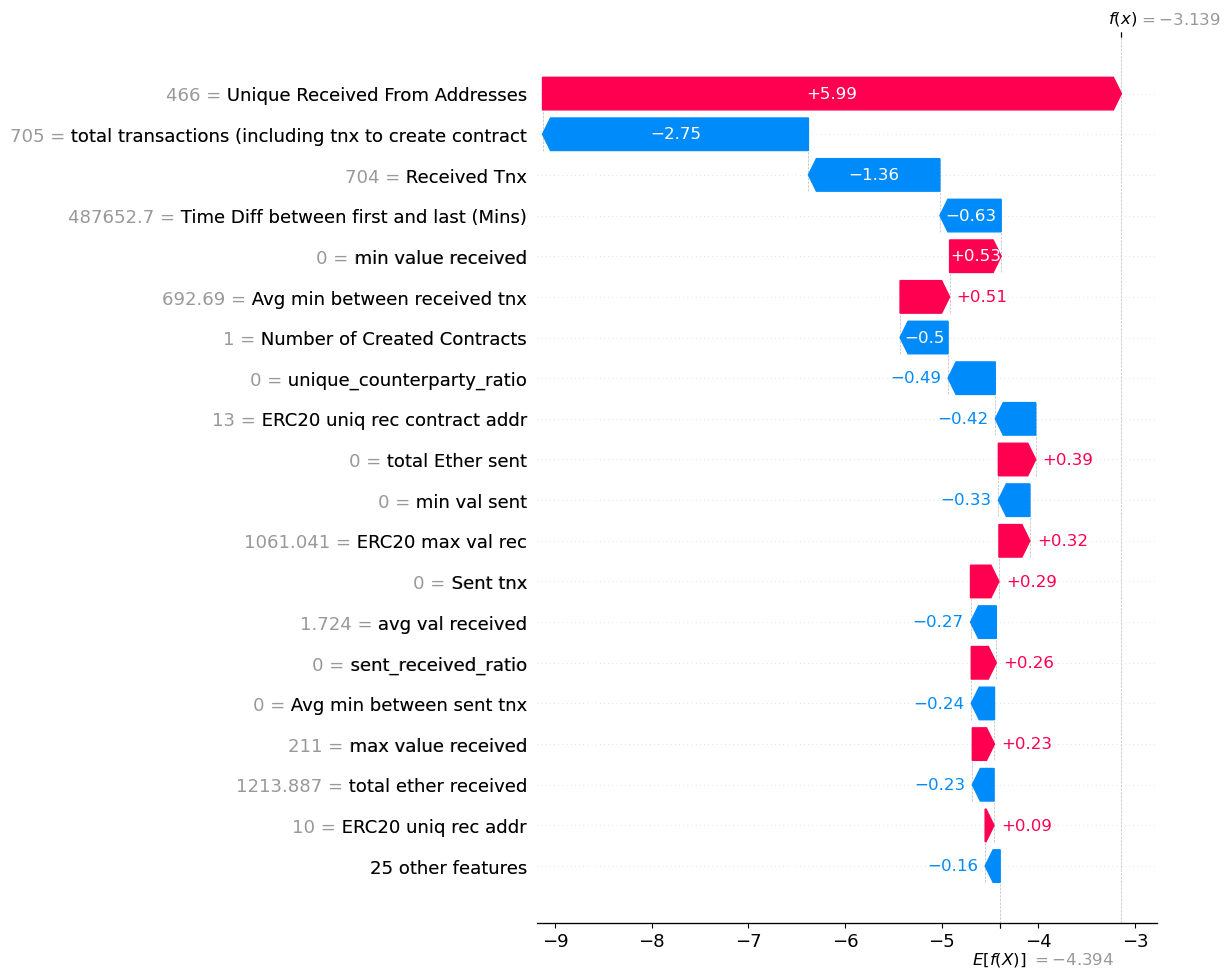

In [ ]:
# 배경 데이터는 너무 크게 잡지 말고 일부만
background = X_trainval.sample(min(200, len(X_trainval)), random_state=42)

# explainer 생성
explainer = shap.Explainer(final_model, background)

# 설명할 샘플 하나 고르기
# 1) 1 / 0 입력
fn_idx = np.where((y_test.to_numpy() == 1) & (test_pred == 0))[0]
row_idx = np.random.choice(fn_idx) if len(fn_idx) > 0 else 0

x_one = X_test.iloc[[row_idx]]

# SHAP 계산
shap_values_one = explainer(x_one)

display(pd.DataFrame({ "실제값": ["사기" if y_test.iloc[row_idx] == 1 else "일반"], "예측값": ["사기" if int(test_pred[row_idx]) == 1 else "일반"], "예측확률": [float(test_proba[row_idx])] }))
# waterfall plot
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values_one[0], max_display=20)
plt.show()

### 모델 저장

In [ ]:
artifact = {
    "model": final_model,
    "feature_cols": X_trainval.columns.tolist(),
    "threshold": best_thr,
    "model_name": best_name,
}

joblib.dump(artifact, "fraud_model_artifact.pkl")

['fraud_model_artifact.pkl']